# TP3 - Análisis de Sentimiento sobre Tweets (Sentiment140)
## Notebook 2 — Entrenamiento y Evaluación (Train / Test)
### Diplomatura IA - UP
### Alumno: Gonzalez Marta Elizabeth
### Mes: Julio26

- **Split de 2 partes** (train/test, 70/30).
- 4 modelos: Naive Bayes, Regresión Logística, Regresión Logística + Feature Engineering, y **TextBlob** (que aunque viene pre-entrenado, se evalúa igual sobre train y test para que la comparación sea justa con TextBlob).

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from scipy.sparse import hstack, csr_matrix
from textblob import TextBlob

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (7,5)

mega = pd.read_csv('../data/processed/mega_clean.csv')
print('Megaset:', mega.shape)
print(mega['target'].value_counts())


Megaset: (1592728, 30)
target
0    796693
4    795896
2       139
Name: count, dtype: int64


## 1. Split Train / Test (70/30, estratificado)

Como además necesitamos otras columnas (el texto **crudo** para evaluar TextBlob, y las features de ingeniería del Notebook 1), reconstruimos los DataFrames `train`/`test` completos usando los mismos índices que generó ese split — así el split es idéntico al de la clase, pero seguimos teniendo acceso a todo lo que necesitamos.

In [9]:
X = mega['clean_text']
y = mega['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Reconstruimos los DataFrames completos (mismas filas que el split de arriba) para tener
# acceso a texto crudo, features de ingeniería, etc.
train = mega.loc[X_train.index].reset_index(drop=True)
test = mega.loc[X_test.index].reset_index(drop=True)

print(f'Train: {len(train):>6} filas | {train["target"].value_counts().to_dict()}')
print(f'Test:  {len(test):>6} filas | {test["target"].value_counts().to_dict()}')

train.to_csv('../data/processed/split_train.csv', index=False)
test.to_csv('../data/processed/split_test.csv', index=False)


Train: 1114909 filas | {0: 557685, 4: 557127, 2: 97}
Test:  477819 filas | {0: 239008, 4: 238769, 2: 42}


## 2. Vectorización TF-IDF

In [10]:
tfidf_check = TfidfVectorizer(ngram_range=(1,2), min_df=5)
tfidf_check.fit(train['clean_text'])
print('Vocabulario real (sin max_features):', len(tfidf_check.vocabulary_))


Vocabulario real (sin max_features): 209392


Con >1.6M documentos de soporte, el riesgo de overfitting por usar más vocabulario es bajo — se usa el vocabulario completo (`max_features=None`).

In [11]:
tfidf = TfidfVectorizer(max_features=None, ngram_range=(1,2), min_df=5)
X_train = tfidf.fit_transform(train['clean_text'])
X_test = tfidf.transform(test['clean_text'])

y_train, y_test = train['target'], test['target']

print('Vocabulario usado:', len(tfidf.vocabulary_))
print('Shape train vectorizado:', X_train.shape)


Vocabulario usado: 209392
Shape train vectorizado: (1114909, 209392)


## 3. Features de ingeniería 
Probamos si sumar estas features a TF-IDF mejora el modelo.

In [12]:
FEATURE_COLS = [
    'n_chars', 'n_words', 'avg_word_len', 'n_exclamation', 'n_question',
    'n_uppercase_words', 'n_elongated', 'n_pos_emoticons', 'n_neg_emoticons',
    'n_mentions_count', 'n_hashtags_count', 'n_lex_pos', 'n_lex_neg', 'lex_pos_neg_diff',
]

scaler = StandardScaler()
X_train_feat = scaler.fit_transform(train[FEATURE_COLS])
X_test_feat = scaler.transform(test[FEATURE_COLS])

X_train_comb = hstack([X_train, csr_matrix(X_train_feat)])
X_test_comb = hstack([X_test, csr_matrix(X_test_feat)])


## 4. TextBlob (pre-entrenado) — evaluado en TRAIN y TEST

TextBlob no se entrena con nuestros datos, pero se evalúa sobre los mismos conjuntos que los demás modelos.

In [13]:
def textblob_predict_3clase(texts, pos_th=0.1, neg_th=-0.1):
    def _pred(t):
        polarity = TextBlob(t).sentiment.polarity
        if polarity > pos_th:
            return 4
        elif polarity < neg_th:
            return 0
        else:
            return 2
    return texts.apply(_pred)

y_train_pred_tb = textblob_predict_3clase(train['text'])
y_test_pred_tb = textblob_predict_3clase(test['text'])

print('TRAIN')
print(classification_report(y_train, y_train_pred_tb, target_names=['Negativo','Neutral','Positivo'], labels=[0,2,4], zero_division=0))
print('TEST')
print(classification_report(y_test, y_test_pred_tb, target_names=['Negativo','Neutral','Positivo'], labels=[0,2,4], zero_division=0))


TRAIN
              precision    recall  f1-score   support

    Negativo       0.78      0.27      0.40    557685
     Neutral       0.00      0.73      0.00        97
    Positivo       0.67      0.52      0.58    557127

    accuracy                           0.39   1114909
   macro avg       0.48      0.51      0.33   1114909
weighted avg       0.73      0.39      0.49   1114909

TEST
              precision    recall  f1-score   support

    Negativo       0.78      0.27      0.40    239008
     Neutral       0.00      0.76      0.00        42
    Positivo       0.67      0.52      0.58    238769

    accuracy                           0.39    477819
   macro avg       0.48      0.52      0.33    477819
weighted avg       0.73      0.39      0.49    477819



## 5. Naive Bayes (BoW/TF-IDF) 


In [14]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

y_train_pred_nb = nb_model.predict(X_train)
y_test_pred_nb = nb_model.predict(X_test)

print('TRAIN')
print(classification_report(y_train, y_train_pred_nb, target_names=['Negativo','Neutral','Positivo'], labels=[0,2,4], zero_division=0))
print('TEST')
print(classification_report(y_test, y_test_pred_nb, target_names=['Negativo','Neutral','Positivo'], labels=[0,2,4], zero_division=0))


TRAIN
              precision    recall  f1-score   support

    Negativo       0.82      0.82      0.82    557685
     Neutral       0.00      0.00      0.00        97
    Positivo       0.82      0.82      0.82    557127

    accuracy                           0.82   1114909
   macro avg       0.55      0.55      0.55   1114909
weighted avg       0.82      0.82      0.82   1114909

TEST
              precision    recall  f1-score   support

    Negativo       0.79      0.79      0.79    239008
     Neutral       0.00      0.00      0.00        42
    Positivo       0.79      0.78      0.79    238769

    accuracy                           0.79    477819
   macro avg       0.52      0.52      0.52    477819
weighted avg       0.79      0.79      0.79    477819



## 6. Regresión Logística (TF-IDF)


In [16]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

y_train_pred_lr = lr_model.predict(X_train)
y_test_pred_lr = lr_model.predict(X_test)

print('TRAIN')
print(classification_report(y_train, y_train_pred_lr, target_names=['Negativo','Neutral','Positivo'], labels=[0,2,4], zero_division=0))
print('TEST')
print(classification_report(y_test, y_test_pred_lr, target_names=['Negativo','Neutral','Positivo'], labels=[0,2,4], zero_division=0))


TRAIN
              precision    recall  f1-score   support

    Negativo       0.84      0.82      0.83    557685
     Neutral       0.00      0.00      0.00        97
    Positivo       0.83      0.85      0.84    557127

    accuracy                           0.83   1114909
   macro avg       0.56      0.56      0.56   1114909
weighted avg       0.83      0.83      0.83   1114909

TEST
              precision    recall  f1-score   support

    Negativo       0.81      0.79      0.80    239008
     Neutral       0.00      0.00      0.00        42
    Positivo       0.80      0.82      0.81    238769

    accuracy                           0.80    477819
   macro avg       0.54      0.54      0.54    477819
weighted avg       0.80      0.80      0.80    477819



## 7. Regresión Logística + Feature Engineering 

In [17]:
lr_fe_model = LogisticRegression(max_iter=1000)
lr_fe_model.fit(X_train_comb, y_train)

y_train_pred_lrfe = lr_fe_model.predict(X_train_comb)
y_test_pred_lrfe = lr_fe_model.predict(X_test_comb)

print('TRAIN')
print(classification_report(y_train, y_train_pred_lrfe, target_names=['Negativo','Neutral','Positivo'], labels=[0,2,4], zero_division=0))
print('TEST')
print(classification_report(y_test, y_test_pred_lrfe, target_names=['Negativo','Neutral','Positivo'], labels=[0,2,4], zero_division=0))


TRAIN
              precision    recall  f1-score   support

    Negativo       0.85      0.84      0.84    557685
     Neutral       0.00      0.00      0.00        97
    Positivo       0.84      0.86      0.85    557127

    accuracy                           0.85   1114909
   macro avg       0.56      0.56      0.56   1114909
weighted avg       0.85      0.85      0.85   1114909

TEST
              precision    recall  f1-score   support

    Negativo       0.82      0.79      0.80    239008
     Neutral       0.00      0.00      0.00        42
    Positivo       0.80      0.82      0.81    238769

    accuracy                           0.81    477819
   macro avg       0.54      0.54      0.54    477819
weighted avg       0.81      0.81      0.81    477819



## 8. Tabla comparativa (resumen de los 4 modelos, Train y Test)

Esto es una síntesis visual de todo lo de arriba — no reemplaza los `classification_report` completos (que ya están impresos en cada sección), solo los resume para comparar de un vistazo.

conjunto                   TRAIN    TEST
modelo                                  
Naive Bayes               0.5460  0.5250
Regresión Logística       0.5565  0.5361
Regresión Logística + FE  0.5637  0.5379
TextBlob (pre-entrenado)  0.3275  0.3272


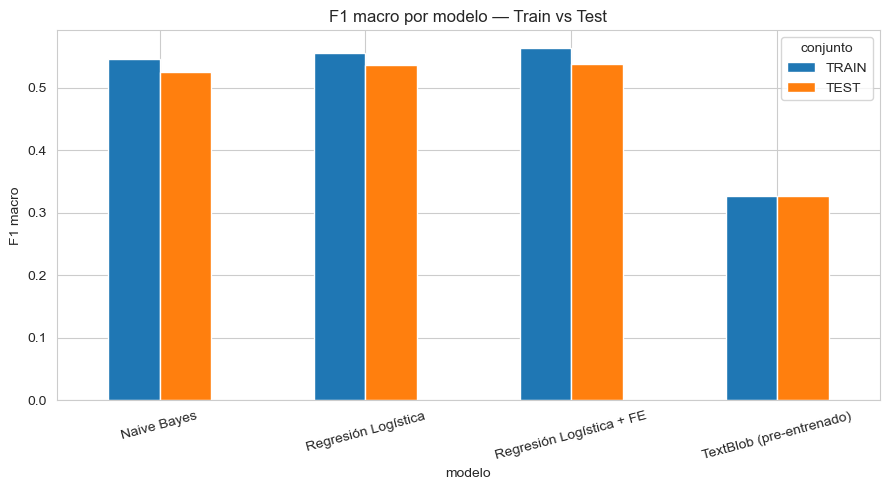

In [20]:
filas = []
predicciones = {
    'TextBlob (pre-entrenado)': (y_train_pred_tb, y_test_pred_tb),
    'Naive Bayes': (y_train_pred_nb, y_test_pred_nb),
    'Regresión Logística': (y_train_pred_lr, y_test_pred_lr),
    'Regresión Logística + FE': (y_train_pred_lrfe, y_test_pred_lrfe),
}

for nombre, (pred_tr, pred_te) in predicciones.items():
    filas.append({
        'modelo': nombre, 'conjunto': 'TRAIN',
        'accuracy': accuracy_score(y_train, pred_tr),
        'f1_macro': f1_score(y_train, pred_tr, average='macro'),
        'f1_neutral': f1_score(y_train, pred_tr, labels=[2], average='macro', zero_division=0),
    })
    filas.append({
        'modelo': nombre, 'conjunto': 'TEST',
        'accuracy': accuracy_score(y_test, pred_te),
        'f1_macro': f1_score(y_test, pred_te, average='macro'),
        'f1_neutral': f1_score(y_test, pred_te, labels=[2], average='macro', zero_division=0),
    })

tabla_completa = pd.DataFrame(filas)
tabla_pivot = tabla_completa.pivot(index='modelo', columns='conjunto', values='f1_macro')[['TRAIN','TEST']]
print(tabla_pivot.round(4).to_string())

tabla_completa.to_csv('../data/processed/tabla_completa_train_test.csv', index=False)

fig, ax = plt.subplots(figsize=(9,5))
tabla_pivot.plot(kind='bar', ax=ax)
ax.set_title('F1 macro por modelo — Train vs Test')
ax.set_ylabel('F1 macro')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('outputs_nb2_comparacion_train_test.png', dpi=110, bbox_inches='tight')
plt.show()


## 9. Matrices de confusión — los 4 modelos, sobre TEST

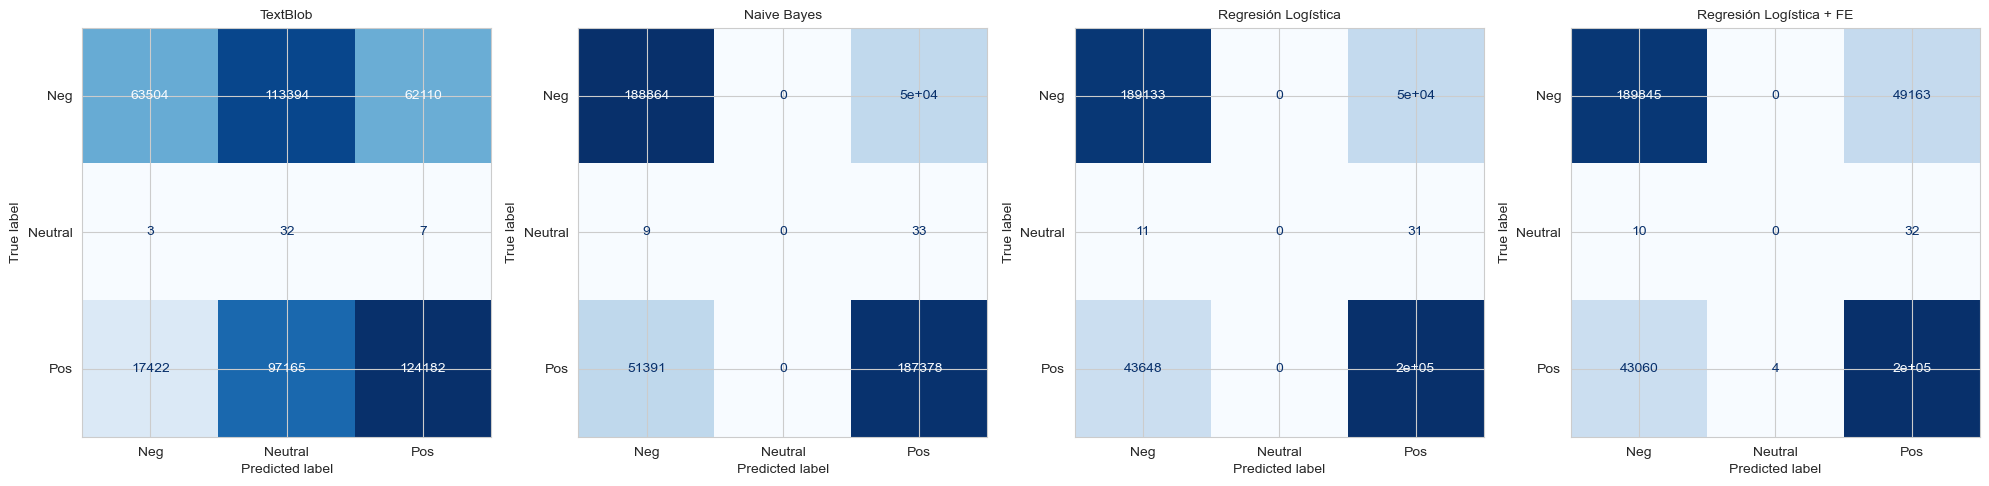

In [21]:
fig, axes = plt.subplots(1, 4, figsize=(20,5))
preds_test_dict = {
    'TextBlob': y_test_pred_tb, 'Naive Bayes': y_test_pred_nb,
    'Regresión Logística': y_test_pred_lr, 'Regresión Logística + FE': y_test_pred_lrfe,
}
for ax, (nombre, pred) in zip(axes, preds_test_dict.items()):
    cm = confusion_matrix(y_test, pred, labels=[0,2,4])
    ConfusionMatrixDisplay(cm, display_labels=['Neg','Neutral','Pos']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(nombre, fontsize=10)
plt.tight_layout()
plt.savefig('outputs_nb2_matrices_confusion.png', dpi=110, bbox_inches='tight')
plt.show()


## 10. Selección del mejor modelo

**Criterio:** F1 macro en TEST — la comparación directa entre train y test para cada modelo (secciones 4-7) además permite ver si algún modelo sobreajusta (F1 de train mucho más alto que el de test).

In [22]:
ranking_test = tabla_completa[tabla_completa['conjunto'] == 'TEST'].sort_values('f1_macro', ascending=False)
print(ranking_test[['modelo','accuracy','f1_macro','f1_neutral']].to_string(index=False))

nombre_ganador = ranking_test.iloc[0]['modelo']
print(f'\nModelo elegido: {nombre_ganador}')

modelos_map = {
    'Naive Bayes': nb_model,
    'Regresión Logística': lr_model,
    'Regresión Logística + FE': lr_fe_model,
}
modelo_final = modelos_map.get(nombre_ganador, None)
if modelo_final is None:
    print('TextBlob fue el ganador — no hay un modelo sklearn entrenado para guardar; se usa la función textblob_predict_3clase directamente.')


                  modelo  accuracy  f1_macro  f1_neutral
Regresión Logística + FE  0.806895  0.537937    0.000000
     Regresión Logística  0.804183  0.536125    0.000000
             Naive Bayes  0.787415  0.524965    0.000000
TextBlob (pre-entrenado)  0.392864  0.327191    0.000304

Modelo elegido: Regresión Logística + FE


## 11. Guardado de modelos y resultados

In [23]:
import pickle

with open('../data/processed/tfidf_vectorizer_mega.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
with open('../data/processed/scaler_features.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('../data/processed/nb_model.pkl', 'wb') as f:
    pickle.dump(nb_model, f)
with open('../data/processed/lr_model_mega.pkl', 'wb') as f:
    pickle.dump(lr_model, f)
with open('../data/processed/lr_fe_model.pkl', 'wb') as f:
    pickle.dump(lr_fe_model, f)
with open('../data/processed/modelo_final_elegido.pkl', 'wb') as f:
    pickle.dump({'nombre': nombre_ganador, 'modelo': modelo_final}, f)

print(f'Guardado. Modelo elegido: {nombre_ganador}')


Guardado. Modelo elegido: Regresión Logística + FE


## 12. Resumen de decisiones — Notebook 2

1. **split simple train/test (70/30)**.
2. **Los 4 modelos (Naive Bayes, Regresión Logística, Regresión Logística + FE, TextBlob) se entrenan (salvo TextBlob) y se evalúan con `classification_report` en TRAIN y en TEST**, impresos secuencialmente para cada uno.
3. Se seleccionó el mejor modelo según F1 macro en test.

**Continúa en `03_analisis_errores.ipynb`** (interpretación de errores del modelo elegido con similitud coseno).